# Práctica para Generación de Mapas

## Librerías

In [5]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [8]:
# capa de entidad, en este caso solo la cdmx
mg_ent = gpd.read_file("data_raw/09_ciudaddemexico.zip!conjunto_de_datos", layer="09ent")
display( mg_ent )

# capa de entidad, en este caso las 16 alcaldias
mg_mun = gpd.read_file("data_raw/09_ciudaddemexico.zip!conjunto_de_datos", layer="09mun")
display( mg_mun )

# capa de entidad, en este caso las 16 alcaldias
mg_loc = gpd.read_file("data_raw/09_ciudaddemexico.zip!conjunto_de_datos", layer="09l")
display( mg_loc )

,CVEGEO,CVE_ENT,NOMGEO,geometry
0,09,09,Ciudad de México,"POLYGON ((2802175.66 843326.718, 2801806.564 8..."


,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,geometry
0,09002,09,002,Azcapotzalco,"POLYGON ((2794859.977 837218.408, 2794861.69 8..."
1,09003,09,003,Coyoacán,"POLYGON ((2800218.995 820661.624, 2800250.439 ..."
2,09004,09,004,Cuajimalpa de Morelos,"POLYGON ((2787229.79 825329.285, 2787272.744 8..."
3,09005,09,005,Gustavo A. Madero,"POLYGON ((2802175.66 843326.718, 2801806.564 8..."
4,09006,09,006,Iztacalco,"POLYGON ((2808145.908 826363.205, 2808144.575 ..."
5,09007,09,007,Iztapalapa,"POLYGON ((2812453.035 823708.051, 2812495.143 ..."
6,09008,09,008,La Magdalena Contreras,"POLYGON ((2792518.205 818323.067, 2792478.173 ..."
7,09009,09,009,Milpa Alta,"POLYGON ((2814877.4 806710.534, 2814871.827 80..."
8,09010,09,010,Álvaro Obregón,"POLYGON ((2794395.922 824857.553, 2794434.245 ..."
9,09011,09,011,Tláhuac,"POLYGON ((2816579.32 817395.961, 2816605.02 81..."


,CVEGEO,CVE_ENT,CVE_MUN,CVE_LOC,NOMGEO,AMBITO,geometry
0,090100001,09,010,0001,Álvaro Obregón,Urbana,"POLYGON ((2794395.922 824857.553, 2794434.245 ..."
1,090120124,09,012,0124,Héroes de 1910,Rural,"POLYGON ((2790456.787 808481.077, 2790465.234 ..."
2,090120290,09,012,0290,La Herradura,Rural,"POLYGON ((2794213.866 807014.135, 2794210.882 ..."
3,090120168,09,012,0168,Chalcuitongo (La Asunción),Rural,"MULTIPOLYGON (((2799620.69 801677, 2799632.478..."
4,090120161,09,012,0161,El Pedregal,Rural,"POLYGON ((2793380.544 806947.796, 2793372.531 ..."
...,...,...,...,...,...,...,...
86,090090152,09,009,0152,San Lorenzo Tlacoyucan,Urbana,"POLYGON ((2811163.903 801756.629, 2811186.042 ..."
87,090090300,09,009,0300,San Nicolás Tetelco,Urbana,"POLYGON ((2816936.769 805383.977, 2817231.461 ..."
88,090150001,09,015,0001,Cuauhtémoc,Urbana,"POLYGON ((2800483.029 832381.312, 2800517.052 ..."
89,090030001,09,003,0001,Coyoacán,Urbana,"POLYGON ((2799635.191 820691.582, 2799698.587 ..."


In [9]:
# Cargar datos
filename = 'data_raw/AGEEML_20254271846882.csv'
cat_loc = pd.read_csv(filename, dtype='str')
# Quitar columnas
cat_loc = cat_loc.drop(['Estatus', 'NOM_ENT', 'NOM_ABR', 'NOM_MUN', 'LATITUD', 'LONGITUD', 
                        'CVE_CARTA', 'POB_MASCULINA', 'POB_FEMENINA'], axis=1)
# convertir números
for col in ['ALTITUD', 'POB_TOTAL', 'TOTAL DE VIVIENDAS HABITADAS']:
    cat_loc[col] = pd.to_numeric(cat_loc[col], errors='coerce')
# Revisar
cat_loc



,CVEGEO,CVE_ENT,CVE_MUN,CVE_LOC,NOM_LOC,AMBITO,LAT_DECIMAL,LON_DECIMAL,ALTITUD,POB_TOTAL,TOTAL DE VIVIENDAS HABITADAS
0,090020001,09,002,0001,Azcapotzalco,U,19.48410200,-99.18436000,2244,432205,134204
1,090030001,09,003,0001,Coyoacan,U,19.35021400,-99.16214600,2247,614447,191646
2,090040001,09,004,0001,Cuajimalpa de Morelos,U,19.35735000,-99.29979200,2780,186693,52530
3,090040010,09,004,0010,Cruz Blanca,R,19.31778400,-99.32401000,2985,728,192
4,090040020,09,004,0020,San Lorenzo Acopilco,U,19.33100400,-99.32568100,2937,26042,6627
...,...,...,...,...,...,...,...,...,...,...,...
719,090130295,09,013,0295,San Sebastian,R,19.26608800,-99.03952800,2231,27,8
720,090140001,09,014,0001,Benito Juarez,U,19.37199200,-99.15785300,2238,434153,176175
721,090150001,09,015,0001,Cuauhtemoc,U,19.44164600,-99.15188400,2230,545884,196593
722,090160001,09,016,0001,Miguel Hidalgo,U,19.40726900,-99.19075400,2264,414470,146828


,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,geometry
0,09002,09,002,Azcapotzalco,"POLYGON ((2794859.977 837218.408, 2794861.69 8..."
1,09003,09,003,Coyoacán,"POLYGON ((2800218.995 820661.624, 2800250.439 ..."
2,09004,09,004,Cuajimalpa de Morelos,"POLYGON ((2787229.79 825329.285, 2787272.744 8..."
3,09005,09,005,Gustavo A. Madero,"POLYGON ((2802175.66 843326.718, 2801806.564 8..."
4,09006,09,006,Iztacalco,"POLYGON ((2808145.908 826363.205, 2808144.575 ..."
5,09007,09,007,Iztapalapa,"POLYGON ((2812453.035 823708.051, 2812495.143 ..."
6,09008,09,008,La Magdalena Contreras,"POLYGON ((2792518.205 818323.067, 2792478.173 ..."
7,09009,09,009,Milpa Alta,"POLYGON ((2814877.4 806710.534, 2814871.827 80..."
8,09010,09,010,Álvaro Obregón,"POLYGON ((2794395.922 824857.553, 2794434.245 ..."
9,09011,09,011,Tláhuac,"POLYGON ((2816579.32 817395.961, 2816605.02 81..."


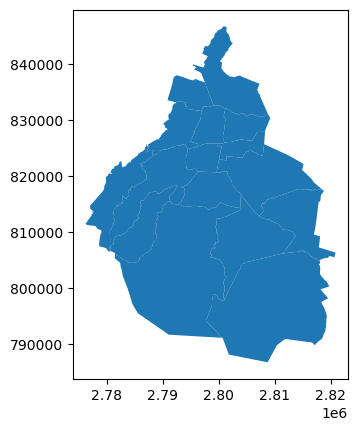

In [10]:
display(mg_mun)
mg_mun.plot()
plt.show()

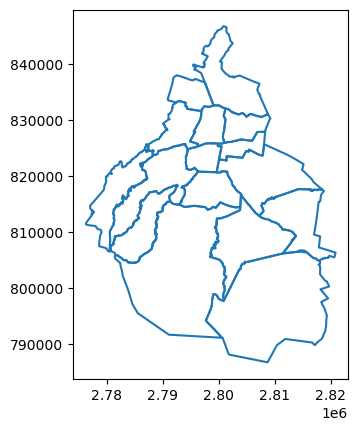

In [11]:
mg_mun.boundary.plot()
plt.show()

In [12]:
mg_mun['geometry'].area

0     3.332309e+07
1     5.362231e+07
2     7.076186e+07
3     8.737831e+07
4     2.296278e+07
5     1.125281e+08
6     6.307477e+07
7     2.967289e+08
8     9.535833e+07
9     8.538328e+07
10    3.128527e+08
11    1.135043e+08
12    2.654892e+07
13    3.233524e+07
14    4.615436e+07
15    3.366605e+07
dtype: float64

In [13]:
cat_loc

,CVEGEO,CVE_ENT,CVE_MUN,CVE_LOC,NOM_LOC,AMBITO,LAT_DECIMAL,LON_DECIMAL,ALTITUD,POB_TOTAL,TOTAL DE VIVIENDAS HABITADAS
0,090020001,09,002,0001,Azcapotzalco,U,19.48410200,-99.18436000,2244,432205,134204
1,090030001,09,003,0001,Coyoacan,U,19.35021400,-99.16214600,2247,614447,191646
2,090040001,09,004,0001,Cuajimalpa de Morelos,U,19.35735000,-99.29979200,2780,186693,52530
3,090040010,09,004,0010,Cruz Blanca,R,19.31778400,-99.32401000,2985,728,192
4,090040020,09,004,0020,San Lorenzo Acopilco,U,19.33100400,-99.32568100,2937,26042,6627
...,...,...,...,...,...,...,...,...,...,...,...
719,090130295,09,013,0295,San Sebastian,R,19.26608800,-99.03952800,2231,27,8
720,090140001,09,014,0001,Benito Juarez,U,19.37199200,-99.15785300,2238,434153,176175
721,090150001,09,015,0001,Cuauhtemoc,U,19.44164600,-99.15188400,2230,545884,196593
722,090160001,09,016,0001,Miguel Hidalgo,U,19.40726900,-99.19075400,2264,414470,146828


In [14]:
cat_loc = gpd.GeoDataFrame(cat_loc, 
                           geometry=gpd.points_from_xy( cat_loc['LON_DECIMAL'], cat_loc['LAT_DECIMAL'])
                          )
cat_loc = cat_loc.set_crs("EPSG:4326")
cat_loc

,CVEGEO,CVE_ENT,CVE_MUN,CVE_LOC,NOM_LOC,AMBITO,LAT_DECIMAL,LON_DECIMAL,ALTITUD,POB_TOTAL,TOTAL DE VIVIENDAS HABITADAS,geometry
0,090020001,09,002,0001,Azcapotzalco,U,19.48410200,-99.18436000,2244,432205,134204,POINT (-99.18436 19.4841)
1,090030001,09,003,0001,Coyoacan,U,19.35021400,-99.16214600,2247,614447,191646,POINT (-99.16215 19.35021)
2,090040001,09,004,0001,Cuajimalpa de Morelos,U,19.35735000,-99.29979200,2780,186693,52530,POINT (-99.29979 19.35735)
3,090040010,09,004,0010,Cruz Blanca,R,19.31778400,-99.32401000,2985,728,192,POINT (-99.32401 19.31778)
4,090040020,09,004,0020,San Lorenzo Acopilco,U,19.33100400,-99.32568100,2937,26042,6627,POINT (-99.32568 19.331)
...,...,...,...,...,...,...,...,...,...,...,...,...
719,090130295,09,013,0295,San Sebastian,R,19.26608800,-99.03952800,2231,27,8,POINT (-99.03953 19.26609)
720,090140001,09,014,0001,Benito Juarez,U,19.37199200,-99.15785300,2238,434153,176175,POINT (-99.15785 19.37199)
721,090150001,09,015,0001,Cuauhtemoc,U,19.44164600,-99.15188400,2230,545884,196593,POINT (-99.15188 19.44165)
722,090160001,09,016,0001,Miguel Hidalgo,U,19.40726900,-99.19075400,2264,414470,146828,POINT (-99.19075 19.40727)


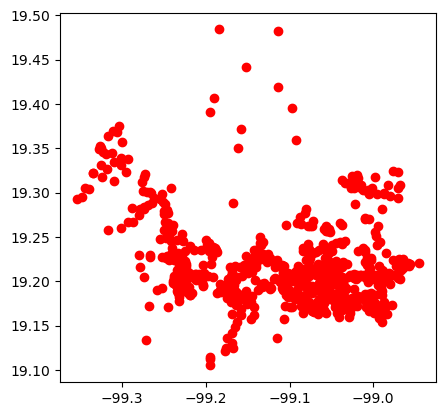

In [15]:
cat_loc.plot(color='red')
plt.show()

In [16]:
df_loc = mg_loc.merge(cat_loc[['CVEGEO', 'AMBITO', 'POB_TOTAL',  'ALTITUD']], on='CVEGEO', how='inner')
df_loc

,CVEGEO,CVE_ENT,CVE_MUN,CVE_LOC,NOMGEO,AMBITO_x,geometry,AMBITO_y,POB_TOTAL,ALTITUD
0,090100001,09,010,0001,Álvaro Obregón,Urbana,"POLYGON ((2794395.922 824857.553, 2794434.245 ...",U,759003,2308
1,090120124,09,012,0124,Héroes de 1910,Rural,"POLYGON ((2790456.787 808481.077, 2790465.234 ...",R,571,2947
2,090120290,09,012,0290,La Herradura,Rural,"POLYGON ((2794213.866 807014.135, 2794210.882 ...",R,793,2794
3,090120168,09,012,0168,Chalcuitongo (La Asunción),Rural,"MULTIPOLYGON (((2799620.69 801677, 2799632.478...",R,1048,2748
4,090120161,09,012,0161,El Pedregal,Rural,"POLYGON ((2793380.544 806947.796, 2793372.531 ...",R,822,2869
...,...,...,...,...,...,...,...,...,...,...
86,090090152,09,009,0152,San Lorenzo Tlacoyucan,Urbana,"POLYGON ((2811163.903 801756.629, 2811186.042 ...",U,4288,2616
87,090090300,09,009,0300,San Nicolás Tetelco,Urbana,"POLYGON ((2816936.769 805383.977, 2817231.461 ...",U,4078,2259
88,090150001,09,015,0001,Cuauhtémoc,Urbana,"POLYGON ((2800483.029 832381.312, 2800517.052 ...",U,545884,2230
89,090030001,09,003,0001,Coyoacán,Urbana,"POLYGON ((2799635.191 820691.582, 2799698.587 ...",U,614447,2247


<Axes: >

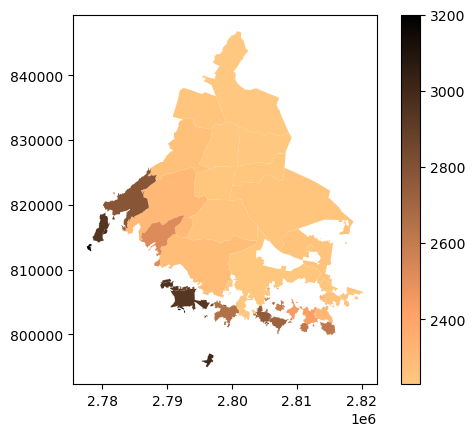

In [17]:
df_loc.plot(column='ALTITUD', cmap='copper_r', legend=True)

In [ ]:
cat_loc = cat_loc.to_crs( mg_mun.crs )

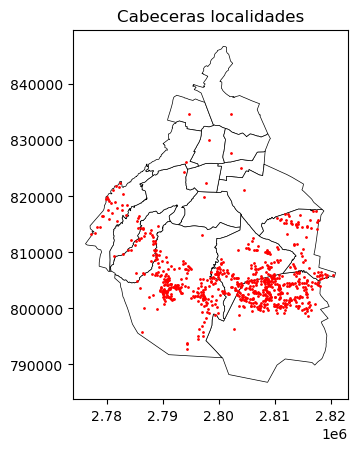

In [19]:
base = mg_mun.plot(color='white', edgecolor='black', linewidth=0.5)
cat_loc.plot(ax=base, color='red', markersize=1)
plt.title('Cabeceras localidades')
plt.show()